# MODELING 1 NOTEBOOK
### This notebook is to perform PCA and clustering on the datasets that I have so far. I will first start off with data in the percents_sa folder, and then move onto the other data.

In [1]:
import pandas as pd
import numpy as np
# import PCA libraries and KNN clustering libraries
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

## Pull the data from the folder

In [5]:
psa = {}
psa['industry'] = pd.read_csv('data/potential_model_features/percents_sa/industry_level_totals_exp.csv')
psa['national'] = pd.read_csv('data/potential_model_features/percents_sa/national_level_totals_exp.csv')
psa['regional'] = pd.read_csv('data/potential_model_features/percents_sa/regional_level_totals_exp.csv')
psa['state'] = pd.read_csv('data/potential_model_features/percents_sa/state_level_totals_exp.csv')

psa['industry'].shape, psa['regional'].shape, psa['national'].shape, psa['state'].shape

((296, 57), (296, 9), (296, 23), (296, 59))

# KNN Clustering
Try a range of numbers of clusters for the industry dataset to see how many clusters are in the dataset. Use the elbow test to find optimal cluster number.

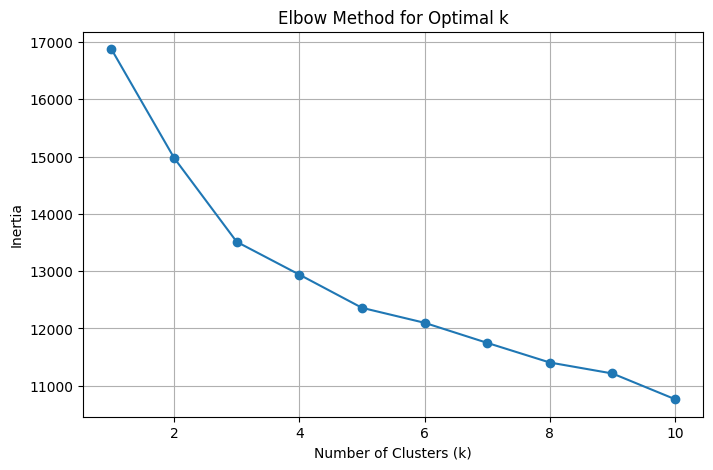

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 1: Load the dataset
industry_df = psa['industry']

# Step 2: Preprocess the data
# Drop non-numeric columns if any, and handle missing values
industry_numeric = industry_df.select_dtypes(include='number').dropna()

# Optional: Standardize the features
scaler = StandardScaler()
industry_scaled = scaler.fit_transform(industry_numeric)

# Step 3: Try a range of cluster numbers
inertia = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(industry_scaled)
    inertia.append(kmeans.inertia_)

# Step 4: Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


Not that many clusters, I don't think I will this clustering here.

In [48]:
# Drop all PCA-derived columns before re-running PCA
industry_df_clean = industry_df.loc[:, ~industry_df.columns.str.startswith('PCA')]

# Run PCA
pca = PCA(n_components=10)
pca_results = pca.fit_transform(industry_df_clean)

# Get top features for PC1
top_features_pc1 = pd.Series(pca.components_[0], index=industry_df_clean.columns).sort_values(ascending=False)
print("Top features in PC1:")
print(top_features_pc1.head(10))

Top features in PC1:
Job Openings: Real estate and rental and leasing -, Monthly, Seasonally Adjusted (All size classes)    0.539123
Job Openings: Information -, Monthly, Seasonally Adjusted (All size classes)                           0.489313
Job Openings: Federal -, Monthly, Seasonally Adjusted (All size classes)                               0.424796
Job Openings: Finance and insurance -, Monthly, Seasonally Adjusted (All size classes)                 0.351677
Quits: Arts, entertainment, and recreation -, Monthly, Seasonally Adjusted (All size classes)          0.127449
Hires: Information -, Monthly, Seasonally Adjusted (All size classes)                                  0.123429
Hires: Durable goods manufacturing -, Monthly, Seasonally Adjusted (All size classes)                  0.111014
Quits: Mining and logging -, Monthly, Seasonally Adjusted (All size classes)                           0.103319
Quits: Wholesale trade -, Monthly, Seasonally Adjusted (All size classes)          

## Run PCA again
But this time only retain the top 4 features that are in the dataframe